# Семинар: Типы данных, условные операторы, циклы.

**TODO: Разобрать аннотации типов в Python.**

## Задача 1.

Вам поручили проанализировать список гостей на свадьбе. В качестве данных вам предоставили два множества: гости со стороны жениха (groom) и гости со стороны невесты (bride). При этом некоторые гости есть в списках и жениха, и невесты одновременно.

Нужно вывести:

* Количество гостей на свадьбе (помните, что некоторые гости есть в списках и жениха, и невесты одновременно)
* Выведите имена общих гостей жениха и невесты отсортированные по алфавиту
* Выведите имена тех гостей, которые не являются общими гостями жениха и невесты отсортированные по алфавиту
* Выведите имена гостей невесты, но только тех, кто не являются при этом гостями жениха отсортированные по алфавиту в обратном порядке

In [12]:
groom = ['Татьяна', 'Мария', 'Ирина', 'Юлия', 'Александр', 'Михаил', 'Максим',
         'Лев', 'Артём', 'Марк', 'Иван', 'Дмитрий', 'Матвей', 'Даниил']
bride = ['Анастасия', 'Елена', 'Даниил', 'Ольга', 'Наталья', 'Екатерина',
         'Анна', 'Татьяна', 'Мария', 'Ирина', 'Юлия', 'Марк', 'Иван']
print(len(groom) + len(bride) - len(set(groom).intersection(set(bride))) == len(set(groom + bride)))
print(sorted(set(groom).intersection(set(bride))))
print(sorted(set(groom) ^ set(bride)))
# print(len(set(groom) ^ set(bride)) + len(set(groom).intersection(set(bride))))
print(sorted(set(bride) - set(groom), reverse=True))

True
['Даниил', 'Иван', 'Ирина', 'Мария', 'Марк', 'Татьяна', 'Юлия']
['Александр', 'Анастасия', 'Анна', 'Артём', 'Дмитрий', 'Екатерина', 'Елена', 'Лев', 'Максим', 'Матвей', 'Михаил', 'Наталья', 'Ольга']
['Ольга', 'Наталья', 'Елена', 'Екатерина', 'Анна', 'Анастасия']


## Задача 2

**a)** Определите функцию `extract_collection`, которая принимает список `input_list` и возвращает два значения: новый список только с целочисленными элементами, а также словарь, где для каждой строки из списка указано количество упоминаний.

In [52]:
from collections import Counter

def extract_collection(input_list: list[float | int | str]) -> tuple[list[int], dict[str, int]]:
    only_int = []
    strings = {}
    counter = Counter(input_list)
    for key, value in counter.items():
        if isinstance(key, int):
            only_int.append(key)
        if isinstance(key, str):
            strings[key] = value
            
    return (only_int, strings)


def a():
    print("i m good func")

# a.__code__ = 
            

my_list = [1, "hello", 5.6, 7, "hello", "Mario"]
print(extract_collection(my_list))  # ([1, 7], {'hello': 2, 'Mario': 1})

([1, 7], {'hello': 2, 'Mario': 1})


**б)** Определите функцию `extract_collection_with_nested`, которая принимает список `input_list` и возвращает два значения: новый список только с целочисленными элементами, а также словарь, где для каждой строки из списка указано количество упоминаний. Если в оригинальном списке были другие списки, их вложенные значения тоже нужно учесть.

In [62]:
import typing as tp
from itertools import chain

PrimitiveTypesT: tp.TypeAlias = float | int | str
ListPrimitiveTypesT: tp.TypeAlias = list[tp.Union[PrimitiveTypesT,'ListPrimitiveTypesT']]


def extract_collection_with_nested(input_list: ListPrimitiveTypesT) -> tuple[list[int], dict[str, int]]:
    flat_list = chain.from_iterable(input_list)
    for i in flat_list:
        print(i)
    return extract_collection(flat_list)
                
            

my_list = [1, "hello", 5.6, 7, "hello", "Mario", [1, 3, 7, "hello", "Alice"]]
print(extract_collection_with_nested(my_list))  # ([1, 7, 1, 3, 7], {'hello': 3, 'Mario': 1, 'Alice': 1})

TypeError: 'int' object is not iterable

## Задача 3. Cумма десятичных дробей

Представим последовательность чисел, где в качестве числителя выступает некоторый неотрицательный индекс (порядковый номер), а знаменателем является число 10. В рамках данной задачи необходимо реализовать алгоритм подсчёта суммы первых N-слагаемых данной последовательности. 

Формула суммы: 1/10 + 2/10 + ... N/10

In [6]:
def print_denary_sum(number: int) -> float:
    return number*(number+1)/2/10

print_denary_sum(4)

1.0

## Задача 4. Стандартное отклонение

В теории вероятности и математической статистике часто используются математическое ожидание и стандартное отклонение. Напишите код, который для заданной последовательности чисел вычисляет стандартное отклонение. Вводится последовательность натуральных чисел, оканчивающаяся числом 0 (само число 0 в последовательность не входит, а служит как признак ее окончания).

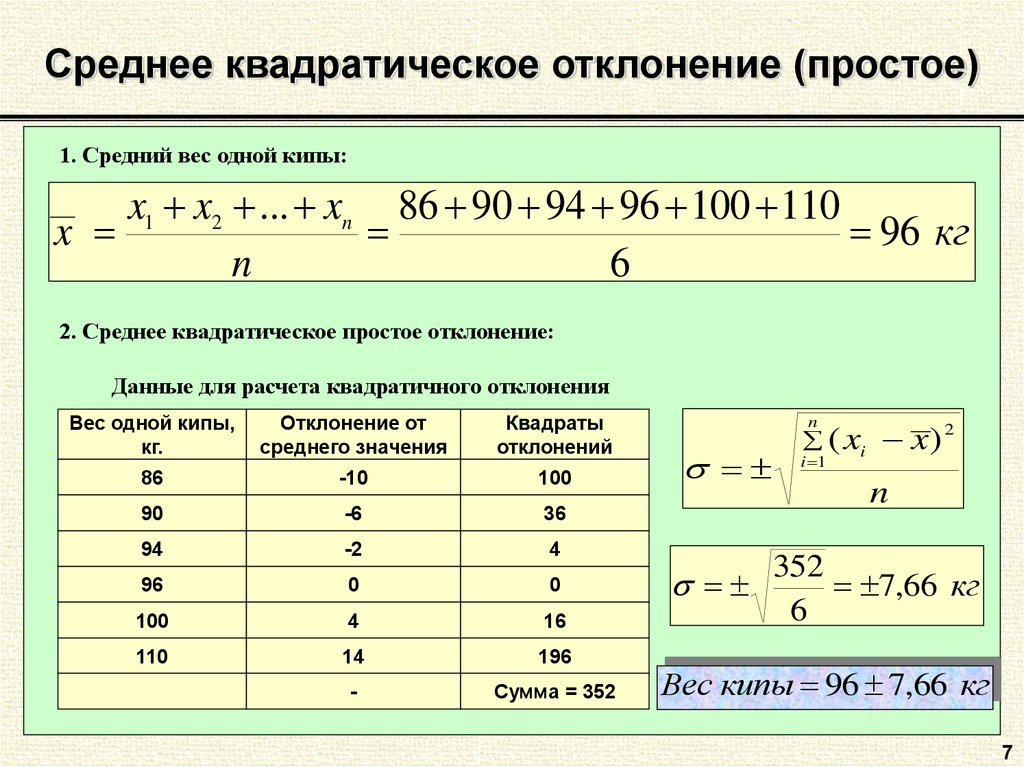

Пример ввода:

1

7

9

0

Ответ: 4.16333199893

In [21]:
def standart_deviage(input_list: list[int]) -> float:
    summary=0
    input_list = input_list[:-1]
    for i in input_list:
        summary+=i
    summary/=len(input_list)

    sum_of_dev=0
    for i in input_list:
        sum_of_dev+=abs(summary-i)**2

    sum_of_dev/=len(input_list)

    return sum_of_dev**0.5


def standart_deviage_with_math(input_list: list[int]) -> float:
    valid_list = input_list[:-1]
    mean = sum(valid_list) / len(valid_list)
    return (sum((x - mean)**2 for x in valid_list) / len(valid_list))**0.5

print(standart_deviage([1,7,9,0]))
print(standart_deviage_with_math([1,7,9,0]))

3.39934634239519
3.39934634239519


## Задача 5.

Для данного числа n<100 закончите фразу “У меня на этой неделе...” одним из возможных продолжений: “n дедлайн”, "n дедлайна”, “n дедлайнов”, правильно склоняя слово “дедлайн”.



- 1 дедлайн_
- 2 дедлайнА
- 3 дедлайнА
- 4 дедлайнА
- 5 дедлайнОВ
- 6 дедлайнОВ
- 7 дедлайнОВ
- 8 дедлайнОВ
- 9 дедлайнОВ
- 10 дедлайнОВ

- 11 дедлайнОВ
- 12 дедлайнОВ
- 13 дедлайнОВ
- 14 дедлайнОВ
- 15 дедлайнОВ
- 16 дедлайнОВ
- 17 дедлайнОВ
- 18 дедлайнОВ
- 19 дедлайнОВ
- 20 дедлайнОВ

- 21 дедлайн_
- 22 дедлайнА
- 23 дедлайнА
- 24 дедлайнА
- 25 дедлайнОВ
- 26 дедлайнОВ
- 27 дедлайнОВ
- 28 дедлайнОВ
- 29 дедлайнОВ
- 30 дедлайнОВ


In [25]:
def deadlines(n: int) -> None:
    for i in range(1, n + 1):
        end = ""
        a = [2, 3, 4]
        ov = [0, 5, 6, 7, 8, 9]
        if i // 10 == 1 or i % 10 in ov:
            end = "ов"
        elif i % 10 in a:
            end = "а"
        print(f"У меня на этой неделе {i} дедлайн{end}")

deadlines(30)

У меня на этой неделе 1 дедлайн
У меня на этой неделе 2 дедлайна
У меня на этой неделе 3 дедлайна
У меня на этой неделе 4 дедлайна
У меня на этой неделе 5 дедлайнов
У меня на этой неделе 6 дедлайнов
У меня на этой неделе 7 дедлайнов
У меня на этой неделе 8 дедлайнов
У меня на этой неделе 9 дедлайнов
У меня на этой неделе 10 дедлайнов
У меня на этой неделе 11 дедлайнов
У меня на этой неделе 12 дедлайнов
У меня на этой неделе 13 дедлайнов
У меня на этой неделе 14 дедлайнов
У меня на этой неделе 15 дедлайнов
У меня на этой неделе 16 дедлайнов
У меня на этой неделе 17 дедлайнов
У меня на этой неделе 18 дедлайнов
У меня на этой неделе 19 дедлайнов
У меня на этой неделе 20 дедлайнов
У меня на этой неделе 21 дедлайн
У меня на этой неделе 22 дедлайна
У меня на этой неделе 23 дедлайна
У меня на этой неделе 24 дедлайна
У меня на этой неделе 25 дедлайнов
У меня на этой неделе 26 дедлайнов
У меня на этой неделе 27 дедлайнов
У меня на этой неделе 28 дедлайнов
У меня на этой неделе 29 дедлайнов
У ме

# Задача 6

Реализуйте функцию extractor для извлечения значений по их строковому пути.
Добавьте опциональный аргумент - "default_value". Сделайте так, чтобы задать его можно было только по имени.

In [31]:
import typing as tp

example = {
    "a": {
        "b": {
            "c": "+++",
        },
    },
    "z": {
        "y": [1,2,3]
    }
}

def extractor(input_dict: dict, composite_key: str, *, default_value = None) -> tp.Any:
    keys = composite_key.split(".")
    ans = dict(input_dict) if keys else default_value
    for i in keys:
        if i in ans:
            ans = ans[i]
        else:
            return default_value

    return ans

extractor(example, "a.b.t")

# Задача 7

Напишите реализацию нескольких функций:
* Функция вычисления числа Фибоначчи по его номеру: n=0 => 0, n=1 => 1, n=2 => 1, n=3 => 2
* Функция вычисления факториала числа
* Функция, которая для переданной последовательности каждый элемент преобразует в число фибоначчи, находит его факториал и выводит сумму полученных чисел.

# Задача 8

Компания Шараш-монтаж установила в квартире систему "умный дом" - это система собирает показания с датчиков температуры в разных комнатах квартиры. Но так как комплектующие везли параллельным импортом, датчики собирают информацию в разных системах измерения.

In [34]:
data = [
    {
        "value": 24.9,
        "measure": "C",
        "source": "Кухня",
        "timestamp": 1772651529
    },
    {
        "value": 24.8,
        "measure": "C",
        "source": "Кухня",
        "timestamp": 1772651515
    },
    {
        "value": 68,
        "measure": "F",
        "source": "Зал",
        "timestamp": 1772651529
    },
    {
        "value": 71.6,
        "measure": "F",
        "source": "Зал",
        "timestamp": 1772651629
    },
    {
        "value": 298.15,
        "measure": "K",
        "source": "Прихожая",
        "timestamp": 1772651628
    },
    {
        "value": 297.15,
        "measure": "K",
        "source": "Прихожая",
        "timestamp": 1772651728
    },
    {
        "value": 296.15,
        "measure": "K",
        "source": "Прихожая",
        "timestamp": 1772651621
    },
]

°К = °С + 273,15

°F = °C × 9/5 + 32

In [42]:
# Напишите функции для конвертации Фаренгейтов и Кельвинов в градусы Цельсия.
def convert_temperature(temperature: float, measure: str) -> float:
    if measure == "K":
        return temperature - 273.15
    if measure == "C": 
        return temperature
    return (temperature - 32) / 9 * 5


for i in data:
    print(convert_temperature(i["value"], i["measure"]))

24.9
24.8
20.0
21.999999999999996
25.0
24.0
23.0


In [38]:
# Данные приходят вразнобой. Напишите функцию, которая сортирует данные по timestamp, а при равном timestamp - по алфавиту source.
# Добавьте аргумент(флаг) для прямой/обратной сортировки.

def sort_temperature(temperatures_data : list, reverse : bool = False) -> list:
    return sorted(temperatures_data, key=lambda x: (x["timestamp"], x["source"]), reverse = reverse)

print(sort_temperature(data))

[{'value': 24.8, 'measure': 'C', 'source': 'Кухня', 'timestamp': 1772651515}, {'value': 68, 'measure': 'F', 'source': 'Зал', 'timestamp': 1772651529}, {'value': 24.9, 'measure': 'C', 'source': 'Кухня', 'timestamp': 1772651529}, {'value': 296.15, 'measure': 'K', 'source': 'Прихожая', 'timestamp': 1772651621}, {'value': 298.15, 'measure': 'K', 'source': 'Прихожая', 'timestamp': 1772651628}, {'value': 71.6, 'measure': 'F', 'source': 'Зал', 'timestamp': 1772651629}, {'value': 297.15, 'measure': 'K', 'source': 'Прихожая', 'timestamp': 1772651728}]


In [40]:
def max_temperature(temperatures_data : list) -> float:
    # cur_max = float("-inf")
    # for el in temperatures_data:
    #     current = convert_temperature(el["value"], el["measure"])
    #     if (current > cur_max):
    #         cur_max = current
    # return cur_max

    return max(convert_temperature(el["value"], el["measure"]) for el in temperatures_data)

print(max_temperature(data))

25.0


In [43]:
# Напишите функцию, которая для заданного источника возвращает строку вида:
# "В комнате <источник> температура принимала значения от <минимальная Т> до <максимальная Т>. Медианная температура: <медиана>"
import statistics

def info(source: str, temperature_data: list) -> str:
    only_source = [data for data in temperature_data if data["source"] == source]
    min_temp = min(convert_temperature(el["value"], el["measure"]) for el in only_source)
    max_temp = max(convert_temperature(el["value"], el["measure"]) for el in only_source)
    median_temp = statistics.median([convert_temperature(el["value"], el["measure"]) for el in only_source])
    return f"В комнате {source} температура принимала значения от {min_temp} до {max_temp}. Медианная температура: {median_temp}"

print(info("Зал", data))
    

В комнате Зал температура принимала значения от 20.0 до 21.999999999999996. Медианная температура: 21.0
